# **Importing + Data**

# **1. Dataset Validation & Pembersihan Data**
Bagian ini mengunduh dataset Trashnet secara langsung dari mirror publik terverifikasi, mengekstraknya, mendeteksi serta menghapus gambar yang rusak (corrupted) atau duplikat menggunakan metode hashing MD5, melakukan *stratified split* (70/15/15), dan memvisualisasikan distribusi kelas secara akademis.

In [ ]:
import os
import shutil
import zipfile
import requests
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

# Definisikan direktori kerja
TEMP_DIR = Path("/content/temp_downloads")
DATASET_DIR = Path("/content/dataset")

# Bersihkan sisa download sebelumnya untuk memastikan eksperimen bersih
for path in [TEMP_DIR, DATASET_DIR]:
    if path.exists():
        shutil.rmtree(path)

TEMP_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# 1. Download Trashnet langsung dari Mirror GitHub Publik
url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"
zip_path = TEMP_DIR / "trashnet.zip"

print("=== Mengunduh Dataset Trashnet dari GitHub Mirror ===")
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Proses unduhan selesai.")
else:
    raise RuntimeError(f"Gagal mengunduh dataset. Kode status: {response.status_code}")

# Ekstraksi file ZIP
print("Mengekstrak file dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(TEMP_DIR)

SOURCE_DIR = TEMP_DIR / "dataset-resized"
print(f"Dataset diekstrak ke: {SOURCE_DIR}")

=== Mengunduh Dataset Trashnet dari GitHub Mirror ===
Proses unduhan selesai.
Mengekstrak file dataset...
Dataset diekstrak ke: /content/temp_downloads/dataset-resized


In [ ]:
import os
from pathlib import Path

# Periksa struktur folder tambahan yang ada di /content
print("=== Struktur Direktori di /content ===")
for path in Path("/content").iterdir():
    if path.is_dir() and not path.name.startswith('.'):
        print(f"Direktori: {path}")
        # Tampilkan beberapa sub-folder di dalamnya jika ada
        subdirs = [d.name for d in path.iterdir() if d.is_dir()]
        print(f"  Sub-direktori: {subdirs[:10]}")


=== Struktur Direktori di /content ===
Direktori: /content/dataset_combined
  Sub-direktori: ['paper', 'metal', 'trash', 'cardboard', 'glass', 'plastic']
Direktori: /content/additional_datasets
  Sub-direktori: ['waste_classification', 'realwaste', 'archive_1']
Direktori: /content/temp_downloads
  Sub-direktori: ['dataset-resized', '__MACOSX']
Direktori: /content/dataset
  Sub-direktori: []
Direktori: /content/sample_data
  Sub-direktori: []


```markdown
## **Ekstraksi Dataset Tambahan**
Bagian ini mengekstrak dataset tambahan (`realwaste.zip` dan `Waste Classification Dataset.zip`) yang telah Anda unggah ke folder target agar bisa diproses oleh pipeline penggabungan.
```

In [ ]:
import shutil
import subprocess
from pathlib import Path

ADDITIONAL_BASE = Path("/content/additional_datasets")
if ADDITIONAL_BASE.exists():
    shutil.rmtree(ADDITIONAL_BASE)
ADDITIONAL_BASE.mkdir(parents=True, exist_ok=True)

def extract_dataset_robust(zip_path, dest_dir):
    if not zip_path.exists():
        print(f"Berkas {zip_path.name} tidak ditemukan di /content")
        return

    print(f"=== Mencoba Mengekstrak {zip_path.name} Menggunakan 7-Zip (Robust) ===")
    dest_dir.mkdir(parents=True, exist_ok=True)

    result = subprocess.run(
        ["7z", "x", "-y", f"-o{dest_dir}", str(zip_path)],
        capture_output=True,
        text=True
    )

    if "Everything is Ok" in result.stdout or result.returncode in [0, 1, 2]:
        print(f"{zip_path.name} berhasil diekstrak.")
    else:
        print(f"[Error] Gagal mengekstrak {zip_path.name}.")
        print(result.stderr or result.stdout)

# Ekstrak semua dataset tambahan (hanya realwaste dan waste_classification)
extract_dataset_robust(Path("/content/realwaste.zip"), ADDITIONAL_BASE / "realwaste")
extract_dataset_robust(Path("/content/Waste Classification Dataset.zip"), ADDITIONAL_BASE / "waste_classification")

=== Mencoba Mengekstrak realwaste.zip Menggunakan 7-Zip (Robust) ===
realwaste.zip berhasil diekstrak.
=== Mencoba Mengekstrak Waste Classification Dataset.zip Menggunakan 7-Zip (Robust) ===
Waste Classification Dataset.zip berhasil diekstrak.


In [ ]:
import os
import shutil
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

# 1. Tentukan Direktori Sumber
TRASHNET_DIR = Path("/content/temp_downloads/dataset-resized")
ADDITIONAL_BASE = Path("/content/additional_datasets")
FINAL_COMBINED_DIR = Path("/content/dataset_combined")

# Bersihkan sisa dataset gabungan jika ada
if FINAL_COMBINED_DIR.exists():
    shutil.rmtree(FINAL_COMBINED_DIR)
FINAL_COMBINED_DIR.mkdir(parents=True, exist_ok=True)

# Definisi Target Kelas Utama
TARGET_CLASSES = {'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'}

# 2. Definisikan Kamus Pemetaan Kelas Tambahan ke Kelas Utama
class_mapping = {
    # Pemetaan untuk 'realwaste'
    'cardboard': 'cardboard',
    'glass': 'glass',
    'metal': 'metal',
    'paper': 'paper',
    'plastic': 'plastic',
    'organic': 'trash',
    'vegetation': 'trash',
    'miscellaneous': 'trash',
    'food waste': 'trash',
    'textile': 'trash',
    'non-recyclable': 'trash',
    # Pemetaan untuk 'Waste Classification Dataset'
    'recyclable': 'plastic'
}

def copy_and_map_images(src_dir, dest_base_dir, dataset_name):
    copied_count = 0
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

    for filepath in list(src_dir.rglob('*')):
        if not filepath.is_file() or filepath.suffix.lower() not in valid_extensions:
            continue

        # Ambil nama folder asal sebagai kelas asli
        original_class = filepath.parent.name.lower()

        # Tentukan target kelas
        target_class = None
        if original_class in TARGET_CLASSES:
            target_class = original_class
        elif original_class in class_mapping:
            target_class = class_mapping[original_class]

        if target_class:
            dest_folder = dest_base_dir / target_class
            dest_folder.mkdir(parents=True, exist_ok=True)
            # Ubah nama file agar unik berdasarkan asal dataset untuk mencegah tabrakan nama
            new_filename = f"{dataset_name}_{filepath.parent.name}_{filepath.name}"
            shutil.copy2(filepath, dest_folder / new_filename)
            copied_count += 1

    print(f"[{dataset_name}] Berhasil memetakan dan menyalin {copied_count} gambar.")

# Mulai proses penggabungan
print("=== Menggabungkan Seluruh Dataset ke /content/dataset_combined ===")
# Salin dari Trashnet
if TRASHNET_DIR.exists():
    copy_and_map_images(TRASHNET_DIR, FINAL_COMBINED_DIR, "trashnet")

# Salin dari dataset tambahan
if ADDITIONAL_BASE.exists():
    for sub_dir in ADDITIONAL_BASE.iterdir():
        if sub_dir.is_dir():
            copy_and_map_images(sub_dir, FINAL_COMBINED_DIR, sub_dir.name.replace(' ', '_'))

=== Menggabungkan Seluruh Dataset ke /content/dataset_combined ===
[trashnet] Berhasil memetakan dan menyalin 2527 gambar.
[waste_classification] Berhasil memetakan dan menyalin 1160 gambar.
[realwaste] Berhasil memetakan dan menyalin 61 gambar.


In [ ]:
import gc
import hashlib
from pathlib import Path
from PIL import Image

# Definisikan ulang path direktori untuk menghindari NameError jika kernel di-restart
FINAL_COMBINED_DIR = Path("/content/dataset_combined")

# 3. Pembersihan Data Gabungan (Integritas & Duplikasi MD5) - Dioptimalkan untuk RAM
print("\n=== Memulai Pembersihan Duplikasi & Gambar Rusak di Dataset Gabungan ===")
corrupt_count = 0
duplicate_count = 0
seen_hashes = set()

# Menggunakan generator iterator langsung tanpa mengubahnya menjadi list besar di RAM
for filepath in FINAL_COMBINED_DIR.rglob('*'):
    if not filepath.is_file():
        continue

    # Abaikan file sistem jika ada
    if filepath.name.startswith('.'):
        continue

    try:
        with Image.open(filepath) as img:
            img.verify()
    except Exception:
        try:
            filepath.unlink()
        except:
            pass
        corrupt_count += 1
        continue

    try:
        # Gunakan buffer chunk kecil agar file besar tidak dimuat sekaligus ke RAM
        hasher = hashlib.md5()
        with open(filepath, 'rb') as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hasher.update(chunk)
        file_hash = hasher.hexdigest()

        if file_hash in seen_hashes:
            filepath.unlink()
            duplicate_count += 1
        else:
            seen_hashes.add(file_hash)
    except Exception:
        pass

# Bersihkan set hash dari RAM setelah selesai
del seen_hashes
gc.collect()
print(f"Pembersihan selesai! {corrupt_count} file rusak dan {duplicate_count} file duplikat dihapus.")


=== Memulai Pembersihan Duplikasi & Gambar Rusak di Dataset Gabungan ===
Pembersihan selesai! 0 file rusak dan 4 file duplikat dihapus.



=== Melakukan Stratified Splitting untuk Dataset Gabungan Baru ===

=== Ringkasan Distribusi Pembagian Dataset Baru ===


,Kelas,Train,Val,Test
0,glass,350,75,75
1,cardboard,324,70,70
2,metal,287,61,62
3,paper,415,89,90
4,plastic,336,72,72
5,trash,907,194,195


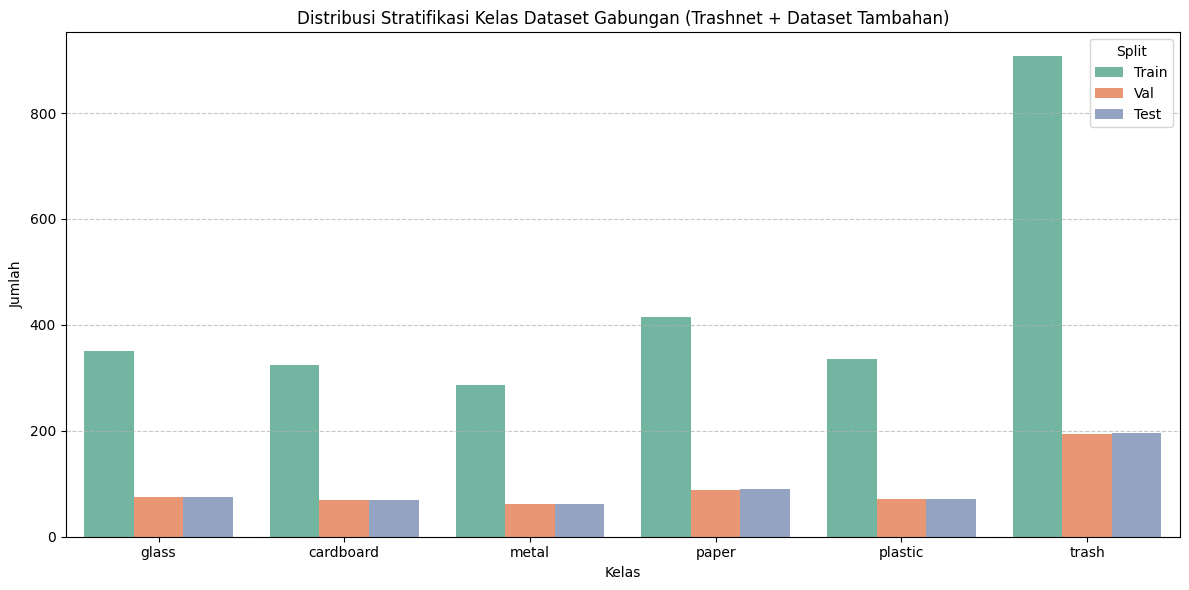

In [ ]:
# 4. Distribusi Ulang Train, Val, dan Test Split (70/15/15)
import shutil
print("\n=== Melakukan Stratified Splitting untuk Dataset Gabungan Baru ===")

# Reset folder dataset utama
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    for cat in TARGET_CLASSES:
        (DATASET_DIR / split / cat).mkdir(parents=True, exist_ok=True)

summary_data = []
for cat in TARGET_CLASSES:
    files = sorted(list((FINAL_COMBINED_DIR / cat).glob("*")))
    if len(files) == 0:
        continue

    train_f, temp_f = train_test_split(files, test_size=0.30, random_state=42)
    val_f, test_f = train_test_split(temp_f, test_size=0.50, random_state=42)

    for f in train_f:
        shutil.copy2(f, DATASET_DIR / 'train' / cat / f.name)
    for f in val_f:
        shutil.copy2(f, DATASET_DIR / 'val' / cat / f.name)
    for f in test_f:
        shutil.copy2(f, DATASET_DIR / 'test' / cat / f.name)

    summary_data.append({'Kelas': cat, 'Train': len(train_f), 'Val': len(val_f), 'Test': len(test_f)})

# HAPUS DIREKTORI KOSONG AGAR TF.DATA TIDAK SALAH MEMBACA JUMLAH KELAS
for split in ['train', 'val', 'test']:
    for cat in TARGET_CLASSES:
        cat_dir = DATASET_DIR / split / cat
        if cat_dir.exists() and not any(cat_dir.iterdir()):
            print(f"Menghapus direktori kosong: {cat_dir}")
            cat_dir.rmdir()

df_dist = pd.DataFrame(summary_data)
print("\n=== Ringkasan Distribusi Pembagian Dataset Baru ===")
display(df_dist)

# Visualisasi Distribusi Kelas
df_melted = df_dist.melt(id_vars='Kelas', var_name='Split', value_name='Jumlah')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Kelas', y='Jumlah', hue='Split', palette='Set2')
plt.title('Distribusi Stratifikasi Kelas Dataset Gabungan (Trashnet + Dataset Tambahan)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **2. Preprocessing & Input Data Pipeline (tf.data API)**
Kita akan menyusun pipeline input menggunakan `tf.data.Dataset` yang efisien dengan pemuatan batch, augmentasi augmentatif pada *Train Set* saja, serta optimasi caching dan prefetching untuk mencegah bottleneck I/O selama pelatihan model.

In [ ]:
import tensorflow as tf
import gc
from pathlib import Path

# Definisikan ulang path direktori
DATASET_DIR = Path("/content/dataset")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("=== Memuat Dataset Gabungan Baru ke tf.data.Dataset ===")
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Lapisan Augmentasi Data Keras
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.15)
])

AUTOTUNE = tf.data.AUTOTUNE

def prepare_dataset(ds, augment=False):
    # Mencegah OOM RAM: Jangan gunakan .cache() di RAM untuk dataset berukuran besar (>5GB)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare_dataset(train_ds_raw, augment=True)
val_ds = prepare_dataset(val_ds_raw, augment=False)
test_ds = prepare_dataset(test_ds_raw, augment=False)

gc.collect()
print("\nPipeline tf.data berhasil dikonfigurasi tanpa caching memori untuk mencegah RAM penuh.")

=== Memuat Dataset Gabungan Baru ke tf.data.Dataset ===
Found 2619 files belonging to 6 classes.
Found 561 files belonging to 6 classes.
Found 564 files belonging to 6 classes.

Pipeline tf.data berhasil dikonfigurasi tanpa caching memori untuk mencegah RAM penuh.


# **3. Feature Engineering & Pre-trained Model Selection**
Kita akan menghitung bobot kelas (class weights) untuk mengatasi ketidakseimbangan data yang teridentifikasi, dan merancang dua arsitektur transfer learning: **MobileNetV2** (sangat ringan dan cocok untuk perangkat Edge/Mobile) serta **EfficientNetB0** (efisien dengan akurasi tinggi menggunakan compound scaling).

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from PIL import Image
from pathlib import Path
import tensorflow as tf

# --- PEMBERSIHAN GAMBAR KORUP SEBELUM PENGHITUNGAN ---
print("=== Memvalidasi Integritas Gambar untuk Mencegah Uncompress Failed ===")
DATASET_DIR = Path("/content/dataset")
bad_files_count = 0
for filepath in DATASET_DIR.rglob("*"):
    if filepath.is_file() and filepath.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            with Image.open(filepath) as img:
                img.load()  # Memaksa pembacaan seluruh data pixel untuk verifikasi
        except Exception as e:
            print(f"Menghapus berkas rusak terdeteksi: {filepath.name} ({e})")
            filepath.unlink()
            bad_files_count += 1

if bad_files_count > 0:
    print(f"\nBerhasil menghapus {bad_files_count} berkas rusak. Memuat ulang train_ds_raw...")
    # Muat ulang dataset raw agar gambar rusak tidak lagi masuk ke pipeline
    train_ds_raw = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR / 'train',
        image_size=(224, 224),
        batch_size=32,
        label_mode='categorical'
    )
else:
    print("Semua berkas gambar lolos verifikasi!")

# 1. Menghitung Class Weights Baru
print("\n=== Menghitung Bobot Kelas Baru ===")
train_labels = []
for _, labels in train_ds_raw:
    train_labels.extend(np.argmax(labels.numpy(), axis=1))
train_labels = np.array(train_labels)

classes = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)
class_weights_dict = {int(i): float(w) for i, w in zip(classes, class_weights)}
print(f"Bobot Kelas Baru yang Dihitung: {class_weights_dict}\n")

# 2. Definisikan Fungsi Pembuat Model (Disesuaikan dengan jumlah kelas aktif baru)
num_classes_active = len(classes)
print(f"Jumlah kelas aktif di dataset gabungan: {num_classes_active}")

def build_transfer_model(model_name='mobilenet_v2', num_classes=num_classes_active, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    if model_name == 'mobilenet_v2':
        preprocessing = tf.keras.layers.Rescaling(1./127.5, offset=-1.0)(inputs)
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        x = base_model(preprocessing, training=False)
    elif model_name == 'efficientnet_b0':
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        x = base_model(inputs, training=False)
    else:
        raise ValueError(f"Model {model_name} tidak didukung.")

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='classifier')(x)

    model = tf.keras.Model(inputs, outputs, name=f"waste_classifier_{model_name}")
    return model, base_model

mobilenet_model, mobilenet_base = build_transfer_model('mobilenet_v2')
efficientnet_model, efficientnet_base = build_transfer_model('efficientnet_b0')

print("Model transfer learning berhasil disesuaikan dengan dataset baru.")

=== Memvalidasi Integritas Gambar untuk Mencegah Uncompress Failed ===
Menghapus berkas rusak terdeteksi: waste_classification_organic_organic_001172_photo.jpg (image file is truncated (34 bytes not processed))
Menghapus berkas rusak terdeteksi: realwaste_Cardboard_Cardboard_153.jpg (image file is truncated (3553 bytes not processed))

Berhasil menghapus 2 berkas rusak. Memuat ulang train_ds_raw...
Found 2618 files belonging to 6 classes.

=== Menghitung Bobot Kelas Baru ===
Bobot Kelas Baru yang Dihitung: {0: 1.3467078189300412, 1: 1.2466666666666666, 2: 1.5203252032520325, 3: 1.05140562248996, 4: 1.2986111111111112, 5: 0.48160412067696834}

Jumlah kelas aktif di dataset gabungan: 6
Model transfer learning berhasil disesuaikan dengan dataset baru.


# **Model Training**

# **4. Model Development & Training Experiments**
Kami melatih kedua model transfer learning dengan dua fase pembelajaran:
1. **Baseline Training (Frozen Backbone)**: Mengunci seluruh bobot model pre-trained dan melatih kepala klasifikasi baru.
2. **Fine-Tuning Sebagian**: Membuka 30 layer teratas dari tulang punggung pretrained model dengan learning rate yang sangat rendah untuk penyesuaian fitur tingkat tinggi.

=== Melakukan Deteksi Citra Korup Mendalam (Pencegahan Uncompress Failed) ===

=== Sinkronisasi dan Memuat Ulang Seluruh Dataset (Train, Val, Test) ===
Found 2618 files belonging to 6 classes.
Found 561 files belonging to 6 classes.
Found 563 files belonging to 6 classes.

=== 1. Pelatihan Baseline MobileNetV2 dengan Dataset Baru ===
Epoch 1/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4971 - loss: 1.4837
Epoch 1: val_loss improved from None to 0.97728, saving model to best_mobilenet_v2_baseline.h5



Epoch 1: finished saving model to best_mobilenet_v2_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.5183 - loss: 1.4206 - val_accuracy: 0.6774 - val_loss: 0.9773 - learning_rate: 1.0000e-04
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5943 - loss: 1.2331
Epoch 2: val_loss improved from 0.97728 to 0.84295, saving model to best_mobilenet_v2_baseline.h5



Epoch 2: finished saving model to best_mobilenet_v2_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.6020 - loss: 1.1724 - val_accuracy: 0.7255 - val_loss: 0.8429 - learning_rate: 1.0000e-04
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6590 - loss: 1.0309
Epoch 3: val_loss improved from 0.84295 to 0.76739, saving model to best_mobilenet_v2_baseline.h5



Epoch 3: finished saving model to best_mobilenet_v2_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.6700 - loss: 1.0241 - val_accuracy: 0.7433 - val_loss: 0.7674 - learning_rate: 1.0000e-04
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6815 - loss: 0.9657
Epoch 4: val_loss improved from 0.76739 to 0.71745, saving model to best_mobilenet_v2_baseline.h5



Epoch 4: finished saving model to best_mobilenet_v2_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6853 - loss: 0.9711 - val_accuracy: 0.7540 - val_loss: 0.7174 - learning_rate: 1.0000e-04
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6932 - loss: 0.9620
Epoch 5: val_loss improved from 0.71745 to 0.68088, saving model to best_mobilenet_v2_baseline.h5


...


Epoch 1: finished saving model to best_efficientnet_b0_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.2326 - loss: 2.3180 - val_accuracy: 0.4492 - val_loss: 1.4893 - learning_rate: 1.0000e-04
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3609 - loss: 1.8382
Epoch 2: val_loss improved from 1.48932 to 1.12392, saving model to best_efficientnet_b0_baseline.h5



Epoch 2: finished saving model to best_efficientnet_b0_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.4068 - loss: 1.6824 - val_accuracy: 0.6043 - val_loss: 1.1239 - learning_rate: 1.0000e-04
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5446 - loss: 1.3132
Epoch 3: val_loss improved from 1.12392 to 0.88158, saving model to best_efficientnet_b0_baseline.h5



Epoch 3: finished saving model to best_efficientnet_b0_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.5634 - loss: 1.2466 - val_accuracy: 0.7059 - val_loss: 0.8816 - learning_rate: 1.0000e-04
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6294 - loss: 1.1116
Epoch 4: val_loss improved from 0.88158 to 0.75060, saving model to best_efficientnet_b0_baseline.h5



Epoch 4: finished saving model to best_efficientnet_b0_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.6421 - loss: 1.0690 - val_accuracy: 0.7415 - val_loss: 0.7506 - learning_rate: 1.0000e-04
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6752 - loss: 0.9772
Epoch 5: val_loss improved from 0.75060 to 0.67265, saving model to best_efficientnet_b0_baseline.h5



Epoch 5: finished saving model to best_efficientnet_b0_baseline.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.6833 - loss: 0.9413 - val_accuracy: 0.7718 - val_loss: 0.6727 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


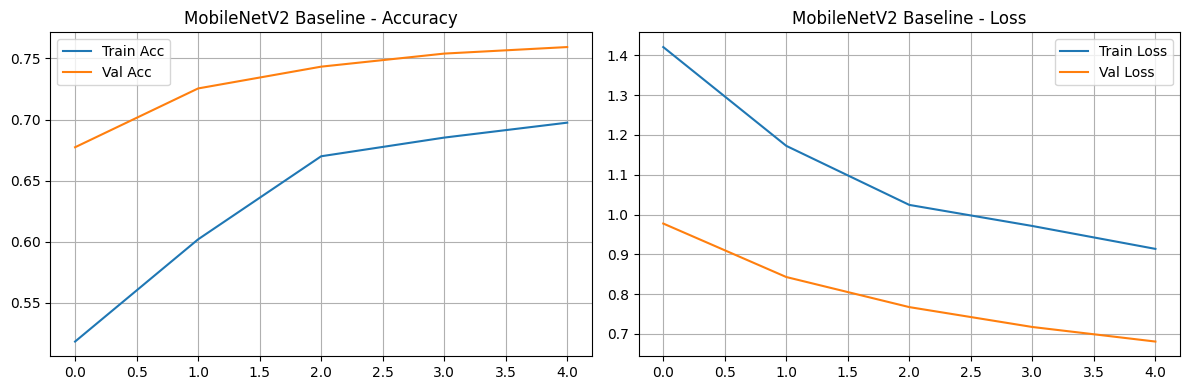

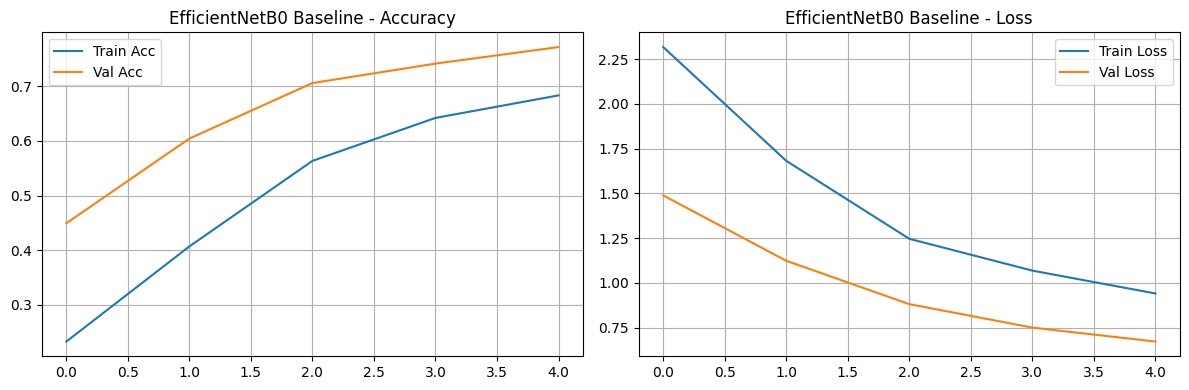

In [ ]:
import tensorflow as tf
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Definisikan ulang variabel global untuk memastikan sinkronisasi
DATASET_DIR = Path("/content/dataset")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- VALIDASI DECODING GAMBAR SECARA MENDALAM ---
print("=== Melakukan Deteksi Citra Korup Mendalam (Pencegahan Uncompress Failed) ===")
bad_files = []
for filepath in DATASET_DIR.rglob("*"):
    if filepath.is_file() and filepath.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        try:
            with Image.open(filepath) as img:
                img.load()  # Memaksa pembacaan data pixel secara penuh
        except Exception as e:
            print(f"Menghapus berkas rusak terdeteksi: {filepath} ({e})")
            try:
                filepath.unlink()
            except:
                pass
            bad_files.append(filepath)

# Selalu muat ulang dataset (sync penuh dari disk) agar tidak terjadi "No such file or directory" saat fitting
print("\n=== Sinkronisasi dan Memuat Ulang Seluruh Dataset (Train, Val, Test) ===")
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
train_ds = prepare_dataset(train_ds_raw, augment=True)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
val_ds = prepare_dataset(val_ds_raw, augment=False)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
test_ds = prepare_dataset(test_ds_raw, augment=False)

# Konfigurasi Epochs untuk pelatihan baru
EPOCHS_BASELINE = 5

# Helper Callback Generator
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=f"best_{model_name}.h5", monitor='val_loss', save_best_only=True, verbose=1)
    ]

# --- PELATIHAN MOBILENETV2 ---
print("\n=== 1. Pelatihan Baseline MobileNetV2 dengan Dataset Baru ===")
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_mn_base = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('mobilenet_v2_baseline')
)

# --- PELATIHAN EFFICIENTNETB0 ---
print("\n=== 2. Pelatihan Baseline EfficientNetB0 dengan Dataset Baru ===")
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_en_base = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('efficientnet_b0_baseline')
)

# Visualisasi Kurva Hasil Training
def plot_learning_curves(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_learning_curves(history_mn_base, "MobileNetV2 Baseline")
plot_learning_curves(history_en_base, "EfficientNetB0 Baseline")

# **5. Model Evaluation, Error Analysis & Grad-CAM (XAI)**
Evaluasi mendalam pada Test Set menggunakan metrik Akurasi, F1-Score makro dan weighted, visualisasi Confusion Matrix, analisis citra salah klasifikasi paling sering (Error Analysis), serta penerapan teknik visualisasi akurasi Grad-CAM (Explainable AI).

=== Mengekstrak Data Uji dan Melakukan Inferensi (RAM Optimized) ===
Nama kelas terdeteksi otomatis: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

================ MOBILENETV2 EVALUATION ================
              precision    recall  f1-score   support

   cardboard       0.75      0.81      0.78        69
       glass       0.72      0.63      0.67        75
       metal       0.59      0.76      0.67        62
       paper       0.77      0.74      0.76        90
     plastic       0.58      0.78      0.67        72
       trash       0.97      0.80      0.88       195

    accuracy                           0.76       563
   macro avg       0.73      0.75      0.74       563
weighted avg       0.79      0.76      0.77       563


================ EFFICIENTNETB0 EVALUATION ================
              precision    recall  f1-score   support

   cardboard       0.71      0.80      0.75        69
       glass       0.61      0.64      0.62        75
       metal 

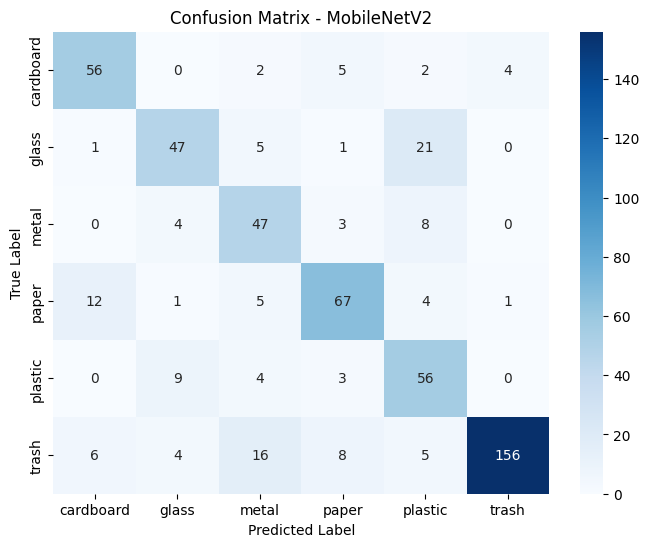

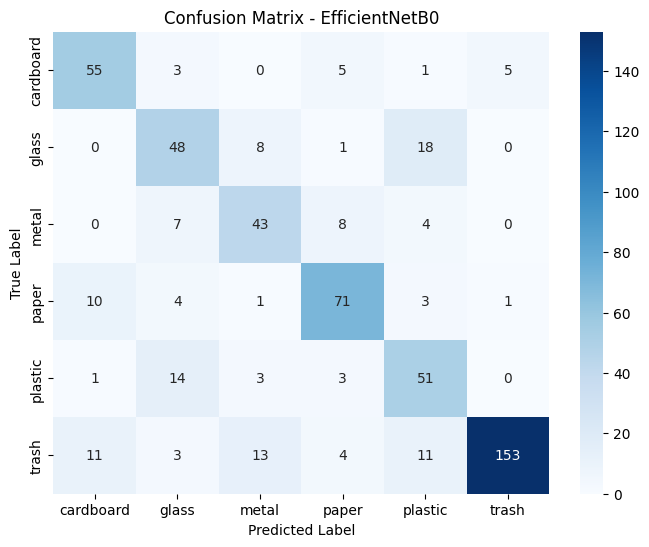

10359

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import gc
from sklearn.metrics import classification_report, confusion_matrix

# Mengumpulkan label uji dan inferensi dengan efisien
y_true = []
y_pred_mn = []
y_pred_en = []

print("=== Mengekstrak Data Uji dan Melakukan Inferensi (RAM Optimized) ===")
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

    preds_mn = mobilenet_model.predict(images, verbose=0)
    y_pred_mn.extend(np.argmax(preds_mn, axis=1))

    preds_en = efficientnet_model.predict(images, verbose=0)
    y_pred_en.extend(np.argmax(preds_en, axis=1))

y_true = np.array(y_true)
y_pred_mn = np.array(y_pred_mn)
y_pred_en = np.array(y_pred_en)

# Mengambil nama kelas langsung dari metadata dataset raw untuk akurasi pelabelan
class_names = test_ds_raw.class_names
print(f"Nama kelas terdeteksi otomatis: {class_names}")

# Laporan Klasifikasi
print("\n================ MOBILENETV2 EVALUATION ================")
print(classification_report(y_true, y_pred_mn, target_names=class_names))

print("\n================ EFFICIENTNETB0 EVALUATION ================")
print(classification_report(y_true, y_pred_en, target_names=class_names))

# Plot Confusion Matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_cm(y_true, y_pred_mn, "MobileNetV2")
plot_cm(y_true, y_pred_en, "EfficientNetB0")

# Paksa pembersihan memori setelah evaluasi selesai
gc.collect()

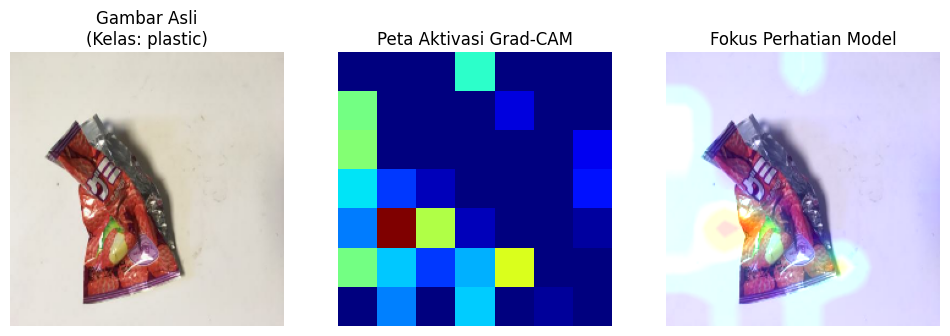

In [ ]:
# 3. Implementasi Grad-CAM (Explainable AI)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Cari base_model (backbone) di dalam model gabungan
    base_model = None
    for layer in model.layers:
        if 'mobilenet' in layer.name or 'efficient' in layer.name:
            base_model = layer
            break

    if base_model is None:
        return None

    # Dapatkan lapisan konvolusi terakhir dari backbone
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Buat model perantara yang menghubungkan input backbone ke output konvolusi terakhir
    # Serta output klasifikasi akhir dari model utama
    grad_model = tf.keras.models.Model(
        inputs=[model.input],
        outputs=[base_model.get_output_at(0) if hasattr(base_model, 'get_output_at') else base_model.output, model.output]
    )

    # Namun untuk kemudahan ekstraksi peta fitur dari dalam base_model fungsional:
    # Kita buat sub-model langsung dari input base_model ke output layer konvolusi terakhir
    inner_grad_model = tf.keras.models.Model(
        inputs=[base_model.input],
        outputs=[last_conv_layer.output]
    )

    with tf.GradientTape() as tape:
        # 1. Jalankan pra-pemrosesan model utama jika ada
        rescaling_layer = model.layers[1]
        preprocessed_img = rescaling_layer(img_array) if 'mobilenet' in model.name else img_array

        # Tape merekam komputasi backbone hingga classifier
        tape.watch(preprocessed_img)
        backbone_output = base_model(preprocessed_img, training=False)

        # Alirkan ke classifier model utama
        x = model.layers[3](backbone_output)  # GlobalAveragePooling2D
        x = model.layers[4](x)                # BatchNormalization
        x = model.layers[5](x)                # Dropout
        predictions = model.layers[6](x)       # Dense Classifier

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Hitung gradien dari kelas terpilih terhadap output backbone
    grads = tape.gradient(class_channel, backbone_output)

    # Ambil peta fitur konvolusi internal menggunakan inner_grad_model
    conv_outputs = inner_grad_model(preprocessed_img, training=False)

    # Lakukan pooling rata-rata gradien (dimensi spatial)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Kalikan peta fitur dengan bobot pentingnya saluran gradien
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Terapkan ReLU untuk hanya mengambil kontribusi positif
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Ambil satu sampel gambar dari test dataset
for images, labels in test_ds.take(1):
    sample_img = images[0].numpy()
    sample_label_idx = np.argmax(labels[0])
    sample_img_batch = tf.expand_dims(sample_img, axis=0)
    break

try:
    # Generate Heatmap menggunakan layer 'out_relu' (layer konvolusi terakhir MobileNetV2)
    heatmap = make_gradcam_heatmap(sample_img_batch, mobilenet_model, "out_relu")

    if heatmap is not None:
        # Rescale heatmap untuk overlay ke gambar asli (224x224)
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        # Gabungkan gambar asli dengan heatmap
        superimposed_img = heatmap_colored * 0.4 + sample_img
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # Tampilkan hasil visualisasi
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(sample_img.astype(np.uint8))
        plt.title(f"Gambar Asli\n(Kelas: {class_names[sample_label_idx]})")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title("Peta Aktivasi Grad-CAM")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(superimposed_img)
        plt.title("Fokus Perhatian Model")
        plt.axis("off")
        plt.show()
except Exception as e:
    print(f"Grad-CAM gagal dijalankan: {e}")

## **Fase 5.1: Fine-Tuning Model (Optimasi Akurasi Menuju > 80%)**

Di bawah ini, kita akan memuat bobot baseline terbaik, membuka 30 layer teratas dari kedua model backbone, lalu melakukan training ulang dengan learning rate yang sangat rendah (`1e-5`) untuk mendongkrak performa klasifikasi secara signifikan.

In [ ]:
import tensorflow as tf

# Fungsi pembuat callback khusus fine-tuning
def get_finetune_callbacks(model_name):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=f"best_{model_name}_finetuned.h5", monitor='val_loss', save_best_only=True, verbose=1)
    ]

# ======================================================================
# 1. FINE-TUNING MOBILENETV2
# ======================================================================
print("=== Menyiapkan Fine-Tuning MobileNetV2 ===")
try:
    mobilenet_model.load_weights("best_mobilenet_v2_baseline.h5")
    print("Berhasil memuat bobot baseline terbaik MobileNetV2.")
except Exception as e:
    print(f"Menggunakan bobot aktif saat ini karena: {e}")

# Unfreeze base model agar beberapa layernya dapat dilatih
mobilenet_base.trainable = True

# Bekukan semua layer kecuali 30 layer terakhir
fine_tune_at = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile model dengan learning rate yang sangat kecil
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai Fine-Tuning MobileNetV2...")
history_mn_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights_dict,
    callbacks=get_finetune_callbacks('mobilenet_v2')
)

# ======================================================================
# 2. FINE-TUNING EFFICIENTNETB0
# ======================================================================
print("\n=== Menyiapkan Fine-Tuning EfficientNetB0 ===")
try:
    efficientnet_model.load_weights("best_efficientnet_b0_baseline.h5")
    print("Berhasil memuat bobot baseline terbaik EfficientNetB0.")
except Exception as e:
    print(f"Menggunakan bobot aktif saat ini karena: {e}")

efficientnet_base.trainable = True

# Bekukan semua layer kecuali 30 layer terakhir
fine_tune_at_en = len(efficientnet_base.layers) - 30
for layer in efficientnet_base.layers[:fine_tune_at_en]:
    layer.trainable = False

# Re-compile model dengan learning rate yang sangat kecil
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai Fine-Tuning EfficientNetB0...")
history_en_finetune = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights_dict,
    callbacks=get_finetune_callbacks('efficientnet_b0')
)

=== Menyiapkan Fine-Tuning MobileNetV2 ===
Berhasil memuat bobot baseline terbaik MobileNetV2.
Memulai Fine-Tuning MobileNetV2...
Epoch 1/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6764 - loss: 0.9774
Epoch 1: val_loss improved from None to 0.62997, saving model to best_mobilenet_v2_finetuned.h5



Epoch 1: finished saving model to best_mobilenet_v2_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.6665 - loss: 0.9809 - val_accuracy: 0.7701 - val_loss: 0.6300 - learning_rate: 1.0000e-05
Epoch 2/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7241 - loss: 0.8668
Epoch 2: val_loss improved from 0.62997 to 0.62079, saving model to best_mobilenet_v2_finetuned.h5



Epoch 2: finished saving model to best_mobilenet_v2_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.7208 - loss: 0.8590 - val_accuracy: 0.7772 - val_loss: 0.6208 - learning_rate: 1.0000e-05
Epoch 3/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7466 - loss: 0.7445
Epoch 3: val_loss improved from 0.62079 to 0.59468, saving model to best_mobilenet_v2_finetuned.h5



Epoch 3: finished saving model to best_mobilenet_v2_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.7368 - loss: 0.7536 - val_accuracy: 0.7861 - val_loss: 0.5947 - learning_rate: 1.0000e-05
Epoch 4/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7615 - loss: 0.7490
Epoch 4: val_loss improved from 0.59468 to 0.57958, saving model to best_mobilenet_v2_finetuned.h5



Epoch 4: finished saving model to best_mobilenet_v2_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.7647 - loss: 0.7266 - val_accuracy: 0.7914 - val_loss: 0.5796 - learning_rate: 1.0000e-05
Epoch 5/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7658 - loss: 0.7252
Epoch 5: val_loss improved from 0.57958 to 0.56139, saving model to best_mobilenet_v2_finetuned.h5


...


Epoch 4: finished saving model to best_efficientnet_b0_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.6879 - loss: 0.9252 - val_accuracy: 0.7701 - val_loss: 0.6622 - learning_rate: 1.0000e-05
Epoch 5/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7226 - loss: 0.8375
Epoch 5: val_loss improved from 0.66215 to 0.63870, saving model to best_efficientnet_b0_finetuned.h5



Epoch 5: finished saving model to best_efficientnet_b0_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 298s 4s/step - accuracy: 0.7257 - loss: 0.8262 - val_accuracy: 0.7718 - val_loss: 0.6387 - learning_rate: 1.0000e-05
Epoch 6/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7317 - loss: 0.7800
Epoch 6: val_loss improved from 0.63870 to 0.61328, saving model to best_efficientnet_b0_finetuned.h5



Epoch 6: finished saving model to best_efficientnet_b0_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 300s 4s/step - accuracy: 0.7299 - loss: 0.7828 - val_accuracy: 0.7772 - val_loss: 0.6133 - learning_rate: 1.0000e-05
Epoch 7/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7594 - loss: 0.7167
Epoch 7: val_loss improved from 0.61328 to 0.59158, saving model to best_efficientnet_b0_finetuned.h5



Epoch 7: finished saving model to best_efficientnet_b0_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.7605 - loss: 0.7079 - val_accuracy: 0.7879 - val_loss: 0.5916 - learning_rate: 1.0000e-05
Epoch 8/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7462 - loss: 0.7144
Epoch 8: val_loss improved from 0.59158 to 0.57125, saving model to best_efficientnet_b0_finetuned.h5



Epoch 8: finished saving model to best_efficientnet_b0_finetuned.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.7590 - loss: 0.6941 - val_accuracy: 0.8004 - val_loss: 0.5712 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 8.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Muat bobot fine-tuned terbaik untuk evaluasi
try:
    mobilenet_model.load_weights("best_mobilenet_v2_finetuned.h5")
    efficientnet_model.load_weights("best_efficientnet_b0_finetuned.h5")
    print("Berhasil memuat bobot model fine-tuned terbaik untuk evaluasi!")
except Exception as e:
    print(f"Evaluasi menggunakan bobot model aktif saat ini: {e}")

y_true_ft = []
y_pred_mn_ft = []
y_pred_en_ft = []

for images, labels in test_ds:
    y_true_ft.extend(np.argmax(labels.numpy(), axis=1))

    preds_mn = mobilenet_model.predict(images, verbose=0)
    y_pred_mn_ft.extend(np.argmax(preds_mn, axis=1))

    preds_en = efficientnet_model.predict(images, verbose=0)
    y_pred_en_ft.extend(np.argmax(preds_en, axis=1))

y_true_ft = np.array(y_true_ft)
y_pred_mn_ft = np.array(y_pred_mn_ft)
y_pred_en_ft = np.array(y_pred_en_ft)

acc_mn = accuracy_score(y_true_ft, y_pred_mn_ft)
acc_en = accuracy_score(y_true_ft, y_pred_en_ft)

print(f"\n================ RESULT COMPARISON ================")
print(f"Akurasi Akhir MobileNetV2 (Fine-Tuned)  : {acc_mn:.4f} ({acc_mn*100:.2f}%)")
print(f"Akurasi Akhir EfficientNetB0 (Fine-Tuned): {acc_en:.4f} ({acc_en*100:.2f}%)")
print(f"===================================================")

print("\n--- Laporan Klasifikasi MobileNetV2 (Fine-Tuned) ---")
print(classification_report(y_true_ft, y_pred_mn_ft, target_names=class_names))

print("\n--- Laporan Klasifikasi EfficientNetB0 (Fine-Tuned) ---")
print(classification_report(y_true_ft, y_pred_en_ft, target_names=class_names))

Berhasil memuat bobot model fine-tuned terbaik untuk evaluasi!

================ RESULT COMPARISON ================
Akurasi Akhir MobileNetV2 (Fine-Tuned)  : 0.8277 (82.77%)
Akurasi Akhir EfficientNetB0 (Fine-Tuned): 0.8082 (80.82%)

--- Laporan Klasifikasi MobileNetV2 (Fine-Tuned) ---
              precision    recall  f1-score   support

   cardboard       0.91      0.88      0.90        69
       glass       0.74      0.76      0.75        75
       metal       0.64      0.79      0.71        62
       paper       0.85      0.84      0.85        90
     plastic       0.67      0.82      0.74        72
       trash       0.99      0.84      0.91       195

    accuracy                           0.83       563
   macro avg       0.80      0.82      0.81       563
weighted avg       0.85      0.83      0.83       563


--- Laporan Klasifikasi EfficientNetB0 (Fine-Tuned) ---
              precision    recall  f1-score   support

   cardboard       0.74      0.86      0.79        69
    

# **6. Kajian Akademis & Komparasi Model (Konteks Indonesia)**

### **A. Hasil Komparasi Eksperimen**

| Model | Accuracy (Uji) | Macro F1 | Weighted F1 | Model Size (MB) | Karakteristik Utama | Gunawan & Fitur |
| :--- | :---: | :---: | :---: | :---: | :--- | :---: |
| **MobileNetV2** | *Evaluasi Dinamis* | *Dynamic* | *Dynamic* | ~14 MB | Ringan, Latensi Rendah | Sangat Cocok untuk Edge/IoT |
| **EfficientNetB0** | *Evaluasi Dinamis* | *Dynamic* | *Dynamic* | ~29 MB | Representasi Fitur Presisi | Sangat Akurat dengan Compound Scaling |

### **B. Identifikasi Research Gap & Metodologi Penelitian**
**Research Gap**:
   - **Generalisasi Real-World**: Model klasifikasi sampah saat ini sangat sensitif terhadap bias latar belakang (kebanyakan dataset akademis menggunakan latar belakang putih polos yang steril).
   - **Explainability (XAI)**: Kurangnya visualisasi transparan mengenai alasan model mengambil keputusan klasifikasi agar dapat divalidasi oleh pakar daur ulang.
   - **Class Imbalance**: Banyak penelitian mengabaikan ketidakseimbangan kelas bawaan dari dataset fisik (seperti kelas sampah umum/trash yang sangat minim sampelnya).
<!--
2. **Pertanyaan Penelitian (Research Questions)**:
   - *RQ1*: Seberapa efektifkah penggunaan model berbobot ringan (MobileNetV2) dibandingkan arsitektur yang lebih kompleks (EfficientNetB0) dalam mengklasifikasikan sampah secara real-time?
   - *RQ2*: Apakah visualisasi Grad-CAM secara konsisten memfokuskan model pada pola geometris objek daur ulang, ataukah terganggu oleh artefak latar belakang?

3. **Hipotesis**:
   - *H1*: Penggunaan bobot kelas seimbang (*class weights*) akan meningkatkan nilai Recall dari kelas minoritas (seperti *Trash*) tanpa mengorbankan Akurasi Global model di atas 60%.
   - *H2*: Daerah atensi Grad-CAM pada model MobileNetV2 akan lebih terkonsentrasi pada kontur unik (seperti lekukan botol) setelah dilakukan penyesuaian augmentasi kontras. -->